# Run 2 — calibrated IEM knobs on the cached distance (FLUX.1-dev, guidance 1.5, m = 3)

Follow-up to [`../flux_lambda_sweep_strong/`](../flux_lambda_sweep_strong/run_694278.ipynb) (job 694278).

**Why this run exists.** 694278 produced a real visual result — the ensemble moved photographic → illustrated —
but the cross-check against [`../demo_properties.ipynb`](../demo_properties.ipynb) showed the reward was running
badly off-calibration, so *what* that movement measures is not trustworthy:

- **$N_\gamma = 6$ against a calibrated $\ge 25$** (Concl. 2). At 6 nodes $f$ is not a converged estimate of the
  IEM integral, and Concl. 2 argues the requirement transfers to high $d$ because $N_\gamma$ resolves a
  *one-dimensional* integral over $\gamma$, independent of the data dimension.
- The $\gamma$ weighting is dominated by the **lowest** interval, not the highest (Concl. 1b: the integrand
  carries a $1/\gamma^{2}$ factor, so the real per-interval weight is $\int d\gamma/\gamma^{2}$), and that
  interval sits on the Euclidean floor where the integrand degenerates to $\|x_1 - x_2\|^{2}$ (Concl. 1a).
- $R = 4$ was forced by cost, not chosen.

**What made the fix affordable.** Commit `e1bfc99` batched and cached the reference score bank. Both previous
jobs ran the *pre-migration* code (694278 finished 18:54, 694286 started 13:49; the commit landed 22:56), so
every cost figure in those notebooks predates it. Post-migration a reward call costs
$(N_\gamma - 1) \cdot N_\epsilon \cdot B$ score rows — **independent of $R$** — and the $R \times R$ normalizer
costs zero extra rows because `batch_scores` reuses the bank. That is what buys $R = 64$.

## Changes

| | 694278 | here |
|---|---|---|
| `R` | 4 | **64** |
| `N_GAMMA` | 6 | **30** |
| `N` (particles) | 8 | **16** |
| `M_TILT` | 5 | **3** |
| `ESS_TARGET` | 0.85 | **0.80** |
| `--time` | 360 min | **480 min** |
| `NUM_EPS`, `MAX_SWEEPS`, `GUIDANCE`, `SEED`, prompt, `N_STEPS`, `IMG`, `GAMMA_LO` | | *unchanged* |

`GUIDANCE` stays at 1.5 — 694278's row 0 was recognisably ordinary photographic dogs, so $p$ was widened
without being broken, and that check does not need repeating.

`M_TILT = 3` because 694278 targeted $m = 5$ and reached $m_{\text{eff}} = 0.67$. Chasing 5 guarantees
truncation at a low $\lambda_{\text{eff}}$; 3 is the largest value with any chance of completing, and it matches
the established sweep rule (try $m \in \{1, 2, 3\}$, take the largest whose diversity holds above ~0.5).

**$\lambda_s$ is not comparable to either previous run.** The $\gamma$ grid changed, and Concl. 1b's
$c_{\text{window}} = \sqrt{\int d\gamma/\gamma^{2}}$ rescales the whole distance — so `m = 3` here means 3σ of
*this* $f$, not of 694278's. Everything is recomputed from the probe below.

### Expect truncation

694278 measured $\Delta\beta \approx 0.019$/level and *shrinking*, so $\beta = 1$ was ~52 levels away. Even at
$m = 3$ that is well beyond 8 h. This is handled the same way it was there: the kernel checkpoints the cloud
every sweep and stops cleanly at a deadline derived from `SLURM_JOB_END_TIME`, and the cells below render
whatever levels completed. The knobs cell projects from a **measured** per-row cost rather than a stale
constant — both previous overruns came from trusting `S_PASS` from an older job.

### Known risk, not fixed in this run

`_scores_at_gamma` issues one forward pass of `NUM_EPS * P` rows with no micro-batching. Building the reference
bank is `NUM_EPS * R = 192` rows — the exact size that OOM-killed job 694256 on a 48 GB card. The knobs cell
prints every forward-batch size this run demands, so the chunking can be planned against real numbers.


In [1]:
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import torch

T_START = time.time()

REPO = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if not os.path.isdir(os.path.join(REPO, "creativity_measure")):
    REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO not in sys.path:
    sys.path.insert(0, REPO)
SWEEP_DIR = os.path.join(REPO, "notebooks", "flux_lambda_sweep_strong_2")
os.makedirs(SWEEP_DIR, exist_ok=True)

# --- wall clock -----------------------------------------------------------------------------------
# The SMC is one long library call, so it cannot be interrupted from outside; the kernel checks
# DEADLINE after every sweep instead. RESERVE_H is held back for decoding and rendering.
# Under Slurm, SLURM_JOB_END_TIME is the job's real end, so the deadline tracks --time automatically.
#
# This run is EXPECTED to hit the deadline. 694278 measured d_beta ~ 0.019/level and shrinking, so
# beta=1 sat ~52 levels away; even at m=3 that is far beyond 8 h. Truncation is safe -- the kernel
# checkpoints the cloud every sweep, so every completed level is already on disk.
#
# RESERVE_H is 1.0 (was 0.75 at N=8): decoding scales with N x levels, and N doubled to 16.
WALL_BUDGET_H = 8.0            # keep in sync with --time in flux_strong_tilt_2.slurm (480 min)
RESERVE_H = 1.0                # held back for VAE decoding, rendering, and writing the notebook
try:
    _end = float(os.environ["SLURM_JOB_END_TIME"])
except (KeyError, ValueError):
    _end = None
if _end and _end > T_START:
    DEADLINE, WALL_BUDGET_H, _src = _end - RESERVE_H * 3600, (_end - T_START) / 3600, "SLURM"
else:
    DEADLINE, _src = T_START + (WALL_BUDGET_H - RESERVE_H) * 3600, "constant"

from creativity_measure import set_default_dtype

set_default_dtype(torch.float32)          # FLUX runs bf16; everything the SMC touches is fp32
torch.manual_seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.bfloat16

from huggingface_hub import auth_check

auth_check("black-forest-labs/FLUX.1-dev")
print(f"device {DEVICE} ({DTYPE})   budget {WALL_BUDGET_H:.2f} h via {_src}")
print(f"SMC deadline {time.strftime('%H:%M:%S', time.localtime(DEADLINE))}")
print("FLUX.1-dev access: OK")


/home/dcor/arielzoizner/miniconda3/envs/creativity-measure/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device cuda (torch.bfloat16)   budget 7.99 h via SLURM
SMC deadline 09:43:53
FLUX.1-dev access: OK


In [2]:
from diffusers import FluxPipeline

MODEL_ID = "black-forest-labs/FLUX.1-dev"
PROMPT = "A dog"

GUIDANCE = 1.5

IMG = 512
C, H, W = 16, IMG // 8, IMG // 8       # VAE downsamples 8x; FLUX latents have 16 channels
LATENT_DIM = C * H * W                 # 65536  (1024^2 would be 262144, and pCN mixes worse)

pipe = FluxPipeline.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)
with torch.no_grad():
    prompt_embeds, pooled_prompt_embeds, text_ids = pipe.encode_prompt(
        prompt=PROMPT, prompt_2=None, device=DEVICE, max_sequence_length=512
    )
# Free both text encoders (~9.5 GB, T5 dominates): the embeddings above are all we need.
pipe.text_encoder = pipe.text_encoder_2 = pipe.tokenizer = pipe.tokenizer_2 = None
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
transformer, vae = pipe.transformer.eval(), pipe.vae.eval()
VAE_SF, VAE_SHIFT = vae.config.scaling_factor, vae.config.shift_factor
print(f"loaded; guidance={GUIDANCE} (baseline used 3.5)  "
      f"guidance_embeds={transformer.config.guidance_embeds}")
print(f"latents ({C}, {H}, {W}) = d {LATENT_DIM}  vae scaling={VAE_SF} shift={VAE_SHIFT}")


def decode(flat: torch.Tensor, chunk: int = 2) -> torch.Tensor:
    """Flat FLUX latents (B, d) -> images (B, 3, 512, 512) in [0, 1].

    Chunked because the VAE decoder, not the transformer, is the memory spike.
    """
    outs = []
    for i in range(0, flat.shape[0], chunk):
        lat = flat[i : i + chunk].reshape(-1, C, H, W).to(DEVICE, DTYPE) / VAE_SF + VAE_SHIFT
        with torch.no_grad():
            img = vae.decode(lat).sample
        outs.append(pipe.image_processor.postprocess(img.float(), output_type="pt").cpu())
    return torch.cat(outs)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:  50%|█████     | 1/2 [00:00<00:00,  3.27it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.51it/s]

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.46it/s]

...

Loading pipeline components...:  71%|███████▏  | 5/7 [00:03<00:01,  1.91it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading pipeline components...:  86%|████████▌ | 6/7 [00:03<00:00,  2.25it/s]

Loading pipeline components...: 100%|██████████| 7/7 [00:03<00:00,  1.82it/s]

loaded; guidance=1.5 (baseline used 3.5)  guidance_embeds=True
latents (16, 64, 64) = d 65536  vae scaling=0.3611 shift=0.1159


In [3]:
from creativity_measure.distances.edm_adapter import chunked_denoiser, edm_score_fn
from creativity_measure.generators.base import edm_generator

SIGMA_MIN, SIGMA_MAX = 2e-3, 80.0
N_STEPS = 8               # Heun ODE steps inside G (15 denoiser evals: 2/step, minus the last corrector)

# --- denoiser batch cap ---------------------------------------------------------------------------
# MEASURED, job 695266 on this exact card/model/resolution (see probe_denoiser_batch.py):
#
#     rows      24     48     96    128    192
#     empty     ok     ok     ok     ok    OOM
#     +bank     ok     ok     ok     ok    OOM      <- bank = the 1.36 GB resident ref score bank
#     free GB 15.8    8.2    2.3    0.6      -      (with the bank held)
#     s/row  0.259  0.251  0.255  0.263      -
#
# R=64 with NUM_EPS=3 needs 192 rows for the reference-bank build (score_bank -> _scores_at_gamma
# issues ONE call of NUM_EPS*R rows per gamma interval), which is exactly the width that OOMs -- and
# the width that killed job 694256. 694278 never exceeded 24 rows because pre-migration R was a loop
# counter, not a batch dimension.
#
# 24 rather than 128: s/row is FLAT across the range, so a narrow cap costs nothing in throughput
# (same number of forward passes, same cost each) and 128 would leave 0.6 GB free for an 8 h run.
# Fixed for the whole run, so f stays a deterministic function of x (CLAUDE.md invariant 1).
MAX_DENOISER_ROWS = 24

# Both must be 2-D in diffusers 0.39; _prepare_latent_image_ids takes the *packed* (half) grid.
img_ids = FluxPipeline._prepare_latent_image_ids(1, H // 2, W // 2, DEVICE, DTYPE)
txt_ids = text_ids if text_ids.ndim == 2 else text_ids[0]


def denoiser(x: torch.Tensor, sigma: torch.Tensor) -> torch.Tensor:
    """EDM denoiser D(x_sigma, sigma) = E[X | x_sigma] backed by the FLUX transformer.

    Flow matching interpolates, EDM adds:  x_t = (1-t)x_0 + t*eps  vs  x_sigma = x_0 + sigma*eps.
    Factoring out (1-t) makes them identical under  t = sigma/(1+sigma),  x_t = x_sigma/(1+sigma).
    FLUX predicts v = eps - x_0, so  x_t - t*v = x_0  exactly -- no approximation.
    Validated by the baseline run: its lambda_eff=0 row decoded to clean, on-prompt images.

    At sigma=80, t = 80/81 ~ 0.988 and x_t ~ z -- unit-scale noise, which is what FLUX expects at
    t -> 1, so sigma_max=80 is the natural choice for these unit-variance latents.

    Returns fp32 (the transformer runs bf16): reward.x_refs pins dtype for the whole SMC, and bf16
    weight/ESS arithmetic would quietly corrupt the beta schedule.
    """
    b = x.shape[0]
    sig = sigma.reshape(b, 1, 1, 1).to(torch.float32)
    t = (sigma / (1.0 + sigma)).to(torch.float32)
    x_t = x.to(torch.float32) / (1.0 + sig)
    packed = FluxPipeline._pack_latents(x_t.to(DTYPE), b, C, H, W)
    with torch.no_grad():
        v = transformer(
            hidden_states=packed,
            timestep=t.to(DTYPE),                                   # forward() scales by 1000 itself
            guidance=torch.full((b,), GUIDANCE, device=x.device, dtype=torch.float32),
            pooled_projections=pooled_prompt_embeds.expand(b, -1).to(DTYPE),
            encoder_hidden_states=prompt_embeds.expand(b, -1, -1).to(DTYPE),
            txt_ids=txt_ids,
            img_ids=img_ids,
            return_dict=False,
        )[0]
    v = FluxPipeline._unpack_latents(v, IMG, IMG, 8).to(torch.float32)
    return (x_t - t.reshape(b, 1, 1, 1) * v).to(torch.float32)


# Wrap ONCE and build both consumers from the wrapper: this covers the generator path
# (heun_prob_flow -> edm_ode_step) and every score path (marginal_score -> score_fn), including the
# reference score_bank build, which is the widest call in the run.
denoiser_capped = chunked_denoiser(denoiser, MAX_DENOISER_ROWS)

G = edm_generator(denoiser_capped, img_shape=(C, H, W), sigma_min=SIGMA_MIN,
                  sigma_max=SIGMA_MAX, n_steps=N_STEPS)
score_fn = edm_score_fn(denoiser_capped, (C, H, W))
print(f"generator + score ready   sigma in [{SIGMA_MIN}, {SIGMA_MAX}]  n_steps={N_STEPS}")
print(f"denoiser batch capped at {MAX_DENOISER_ROWS} rows "
      f"(measured ceiling 128, OOM at 192; s/row flat so the cap is free)")


generator + score ready   sigma in [0.002, 80.0]  n_steps=8
denoiser batch capped at 24 rows (measured ceiling 128, OOM at 192; s/row flat so the cap is free)


In [4]:
from creativity_measure import SquaredGlobalIEMDistance
from creativity_measure.tilt import NormalizedExpectedDistanceReward

# --- knobs ----------------------------------------------------------------------------------------
# R and N_GAMMA are the point of this run. Both were pinned by cost before commit e1bfc99 batched and
# cached the reference score bank; now a reward call costs (N_GAMMA-1)*NUM_EPS*B score rows,
# INDEPENDENT of R, and the R x R normalizer costs zero extra rows (pairwise() reuses the bank when
# X is x_refs). R is therefore a one-time bank cost, not a per-sweep cost.
# (All three claims are asserted by tests/test_global_iem.py::test_denoiser_call_counts.)
#
# N_GAMMA = 30 is the correctness fix: demo_properties.ipynb Concl. 2 finds f converges only for
# N_gamma >= 25 and argues the bound transfers to high d (a 1-D integral over gamma, independent of d).
# At the old N_GAMMA=6 the reward was not a converged IEM estimate, so 694278's conclusion about WHAT
# f measures cannot be trusted. 30 gives a little margin over the calibrated floor.
#
# GAMMA_LO is deliberately left at 1/S^2 (C = 1.00) rather than Concl. 1d's adopted C = 0.75, so that
# N_GAMMA is the ONLY reward-side variable moving against 694278. Concl. 1b says the lowest interval
# carries most of the weight, so the window is the next thing to vary -- but not in the same run.
R, N_GAMMA, NUM_EPS = 64, 30, 3
N = 16
MAX_SWEEPS = 24
M_TILT = 3.0       
ESS_TARGET = 0.80
SEED = 101

# lambda_s = 1/std_p(f) is estimated from PROBE_SIZE draws. 694278 used 8 and the estimate did not
# replicate: the probe gave std 0.0039 while its own level-0 cloud (also 8 draws from p) gave 0.0140,
# a 3.6x disagreement that made LAM_MAX -- and every sigma-unit figure in the results table -- soft.
# Normal-theory SE on a std scales as 1/sqrt(2(n-1)): 8 -> 27%, 32 -> 13%.
PROBE_SIZE = 32

# --- forward batches: what the cell-3 cap turns them into ------------------------------------------
# `_scores_at_gamma` issues ONE marginal_score call on NUM_EPS*P rows and `edm_generator` runs G on
# the full batch it is handed, so uncapped the ref-bank build would ask for NUM_EPS*R = 192 rows --
# measured to OOM on this card (job 695266: 128 ok with 0.6 GB free, 192 OOM), and the width that
# killed job 694256. `chunked_denoiser` splits every entry below into blocks of MAX_DENOISER_ROWS.
# Printed before anything allocates, so a crash still leaves the numbers in the log.
print(f"forward batches this run demands, capped at {MAX_DENOISER_ROWS} rows:")
for _lbl, _rows in (("G(z) on refs", R), ("G(z) on probe", PROBE_SIZE), ("G(z) per sweep", N),
                    ("score: ref bank", NUM_EPS * R), ("score: probe reward", NUM_EPS * PROBE_SIZE),
                    ("score: sweep reward", NUM_EPS * N)):
    _calls = -(-_rows // MAX_DENOISER_ROWS)
    print(f"  {_lbl:22s} {_rows:4d} rows -> {_calls:2d} call(s) x <= {min(_rows, MAX_DENOISER_ROWS)}")
print(f"  ref bank VRAM held for the whole run: (N_GAMMA-1)*NUM_EPS*R*d*4 = "
      f"{(N_GAMMA - 1) * NUM_EPS * R * LATENT_DIM * 4 / 2**30:.2f} GB "
      f"(measured: leaves ~15.8 GB free at a 24-row cap)")
print()

gen = torch.Generator(device="cpu").manual_seed(7)
with torch.no_grad():
    latent_refs = G(torch.randn(R, LATENT_DIM, generator=gen).to(DEVICE))

S = latent_refs.std().item()
GAMMA_LO = max(1.0 / S**2, 1.0 / SIGMA_MAX**2)      # from the DATA scale, not sigma_max (pure noise)
GAMMA_HI = min(2.0**10, 1.0 / SIGMA_MIN**2)         # both clamped to the denoiser's valid range
GAMMAS = torch.logspace(math.log2(GAMMA_LO), math.log2(GAMMA_HI), N_GAMMA, base=2).to(DEVICE)
D2 = SquaredGlobalIEMDistance(None, GAMMAS, num_eps=NUM_EPS, seed=123, score_fn=score_fn)

t0 = time.time()
reward = NormalizedExpectedDistanceReward(distance=D2, x_refs=latent_refs)   # builds the ref bank
t_norm = time.time() - t0
print(f"refs {tuple(latent_refs.shape)}  S={S:.3f}  gamma=[{GAMMA_LO:.3g}, {GAMMA_HI:.3g}]"
      f" x {N_GAMMA}   ref bank + normalizer {t_norm:.0f}s")
print(f"  (at R=4/N_GAMMA=6 this step took 75 s; it now covers 16x the refs and 5x the gamma nodes,")
print(f"   and the R x R normalizer itself is free -- it reuses the cached bank)")

# --- lambda scale ---------------------------------------------------------------------------------
# lam_s = 1/std_p(f), so m = lambda * std_p(f) is tilt strength in units of f's spread under p.
#
# NOT COMPARABLE ACROSS RUNS. The gamma grid changed, and Concl. 1b's c_window = sqrt(int dgamma/g^2)
# rescales the whole distance, so "m = 3" here is 3 sigma of THIS f -- not of 694278's and not of the
# guidance-3.5 baseline's. For the record, prior std_p(f): 0.0203 (g=3.5, N_gamma=6),
# 0.0039 probe / 0.0140 level-0 (g=1.5, N_gamma=6). Expect a different value again; that is correct,
# not a bug. The one hypothesis already killed is "a wider p spreads f more" -- it did the opposite.
t0 = time.time()
with torch.no_grad():
    f_probe = reward(G(torch.randn(PROBE_SIZE, LATENT_DIM, generator=gen).to(DEVICE)))
t_probe = time.time() - t0
f_std = float(f_probe.std())
lam_s = (1.0 / f_std) if f_std > 0 else float("inf")
LAM_MAX = M_TILT * lam_s
print(f"\nf ~ p on {PROBE_SIZE} draws: mean={float(f_probe.mean()):.4f} std={f_std:.4f} "
      f"range=[{float(f_probe.min()):.4f}, {float(f_probe.max()):.4f}]")
print(f"lambda_s = {lam_s:.2f}   LAM_MAX = {M_TILT:.0f} * lambda_s = {LAM_MAX:.1f}")

print(f"\n{'m':>5} {'lambda':>10} {'ESS/N':>7}   (one-shot IS from p to q_lambda)")
for m in sorted({1.0, 2.0, M_TILT, 5.0, 10.0}):
    w = torch.softmax(m * lam_s * f_probe, dim=0)
    print(f"{m:5.1f} {m * lam_s:10.1f} {float(1.0 / (w.pow(2).sum() * PROBE_SIZE)):7.2f}"
          + ("   <- this run" if m == M_TILT else ""))

# --- cost projection, from a MEASURED per-row cost -------------------------------------------------
# Both previous overruns came from a projection built on a constant carried over from an older job
# (S_PASS = 0.174 s, job 693836). Everything below is derived from t_probe, measured seconds ago on
# this card at this configuration. Job 695266 measured 0.246-0.263 s/row directly, flat across batch
# widths 24..128 -- so the 24-row cap costs no throughput, and s_row should land near 0.25.
#
# Rows are denoiser forward passes. Per particle: G(z) costs 2*N_STEPS-1 (Heun), the reward costs
# (N_GAMMA-1)*NUM_EPS with the refs cached. At N_GAMMA=30 that is 15 vs 87 -- the reward is ~85% of a
# sweep, which is why N_STEPS is NOT worth trimming (8->4 would save under 8%).
GEN_ROWS = 2 * N_STEPS - 1                    # rows per particle for G(z)
REW_ROWS = (N_GAMMA - 1) * NUM_EPS            # rows per particle per reward call (refs cached)
s_row = t_probe / (PROBE_SIZE * (GEN_ROWS + REW_ROWS))
t_sweep = N * (GEN_ROWS + REW_ROWS) * s_row

budget_s = (WALL_BUDGET_H - RESERVE_H) * 3600 - (time.time() - T_START)
sweeps_afford = budget_s / t_sweep
print(f"\nmeasured {s_row:.3f} s/row  ({GEN_ROWS} G + {REW_ROWS} reward rows per particle)")
print(f"  independent checks: 0.250 s/row from 694278's 165 s sweep, 0.25 s/row from job 695266")
print(f"  sweep of N={N}: {t_sweep / 60:.1f} min      budget left: {budget_s / 3600:.2f} h "
      f"-> ~{sweeps_afford:.0f} sweeps")

# Levels: 694278 averaged 15.7 sweeps/level at cap 24. d_beta was 0.019/level at m=5 and shrinking;
# smaller m should widen the steps, so scale as 1/m -- a rough guess, flagged as such.
SWEEPS_PER_LEVEL, DBETA_AT_M5 = 15.7, 0.019
levels_afford = sweeps_afford / SWEEPS_PER_LEVEL
dbeta_est = DBETA_AT_M5 * 5.0 / M_TILT
print(f"  at {SWEEPS_PER_LEVEL} sweeps/level (694278's mean at the same cap): "
      f"~{levels_afford:.1f} levels")
print(f"  d_beta guess {dbeta_est:.3f}/level (694278's {DBETA_AT_M5} at m=5, scaled 1/m) "
      f"-> beta ~ {min(1.0, levels_afford * dbeta_est):.2f}, "
      f"lambda_eff ~ {M_TILT * min(1.0, levels_afford * dbeta_est):.1f} sigma")
if levels_afford * dbeta_est < 1.0:
    print("  -> TRUNCATION EXPECTED. Every completed level is checkpointed; this is accepted.")
else:
    print("  -> should reach beta = 1")


forward batches this run demands, capped at 24 rows:
  G(z) on refs             64 rows ->  3 call(s) x <= 24
  G(z) on probe            32 rows ->  2 call(s) x <= 24
  G(z) per sweep           16 rows ->  1 call(s) x <= 16
  score: ref bank         192 rows ->  8 call(s) x <= 24
  score: probe reward      96 rows ->  4 call(s) x <= 24
  score: sweep reward      48 rows ->  2 call(s) x <= 24
  ref bank VRAM held for the whole run: (N_GAMMA-1)*NUM_EPS*R*d*4 = 1.36 GB (measured: leaves ~15.8 GB free at a 24-row cap)



refs (64, 65536)  S=1.015  gamma=[0.971, 1.02e+03] x 30   ref bank + normalizer 1404s
  (at R=4/N_GAMMA=6 this step took 75 s; it now covers 16x the refs and 5x the gamma nodes,
   and the R x R normalizer itself is free -- it reuses the cached bank)



f ~ p on 32 draws: mean=0.9984 std=0.0108 range=[0.9846, 1.0325]
lambda_s = 92.20   LAM_MAX = 3 * lambda_s = 276.6

    m     lambda   ESS/N   (one-shot IS from p to q_lambda)
  1.0       92.2    0.20
  2.0      184.4    0.05
  3.0      276.6    0.03   <- this run
  5.0      461.0    0.03
 10.0      922.0    0.03

measured 0.251 s/row  (15 G + 87 reward rows per particle)
  independent checks: 0.250 s/row from 694278's 165 s sweep, 0.25 s/row from job 695266
  sweep of N=16: 6.8 min      budget left: 6.19 h -> ~54 sweeps
  at 15.7 sweeps/level (694278's mean at the same cap): ~3.5 levels
  d_beta guess 0.032/level (694278's 0.019 at m=5, scaled 1/m) -> beta ~ 0.11, lambda_eff ~ 0.3 sigma
  -> TRUNCATION EXPECTED. Every completed level is checkpointed; this is accepted.


In [5]:
from creativity_measure import LevelSnapshot, PCNKernel, adaptive_tempering_smc_sample

CONFIG = {
    "model_id": MODEL_ID, "img": IMG, "C": C, "H": H, "W": W, "latent_dim": LATENT_DIM,
    "vae_scaling_factor": VAE_SF, "vae_shift_factor": VAE_SHIFT,
    "N": N, "m_tilt": M_TILT, "lam_max": LAM_MAX, "lam_s": lam_s, "ess_target": ESS_TARGET,
    "n_mcmc": None, "max_n_mcmc": MAX_SWEEPS, "seed": SEED, "prompt": PROMPT,
    "guidance": GUIDANCE, "n_steps": N_STEPS, "sigma_min": SIGMA_MIN, "sigma_max": SIGMA_MAX,
    "R": R, "n_gamma": N_GAMMA, "num_eps": NUM_EPS, "gamma_lo": GAMMA_LO, "gamma_hi": GAMMA_HI,
    "probe_size": PROBE_SIZE, "f_std_p": f_std, "data_scale_S": S,
    "t_norm_s": t_norm, "t_probe_s": t_probe, "s_row": s_row, "t_sweep_s": t_sweep,
}
PARTIAL_CKPT = os.path.join(SWEEP_DIR, f"partial_N{N}_m{M_TILT:.0f}_seed{SEED}.pt")


class DeadlineReached(RuntimeError):
    """Raised by the kernel when the wall-clock deadline passes, to stop the SMC cleanly."""


class CheckpointingPCNKernel(PCNKernel):
    """Persists the cloud every sweep and stops the run at a wall-clock deadline.

    Only *reads* state after `super().step()` has run, so no randomness is consumed and no value
    changes: the run is bit-identical to one using a plain PCNKernel (verified on the 2D toy against
    X, logw, betas, ess_history, n_mcmc_history and stop_reason_history).

    Keying by `beta` is the trick -- beta changes only between levels, so each entry is overwritten
    within a level and ends up holding that level's LAST sweep, i.e. exactly the post-rejuvenation
    cloud the final snapshot records. `init` is overridden too, so the beta=0 anchor is captured.
    Writes are temp-file + os.replace, so a kill mid-write cannot corrupt the last good file.
    `ancestors` is arange here (resampling happens outside the kernel); the final save has the real ones.
    """

    def __init__(self, *a, path, config, deadline, save_z=True, **kw):
        super().__init__(*a, **kw)
        self._path, self._config, self._deadline, self._save_z = path, config, deadline, save_z
        self._latest, self._sweeps_at, self._sweeps = {}, {}, 0

    def _record(self, state, *, beta, lam, acc):
        e = {"beta": beta, "lam_eff": beta * lam,
             "X": state.X.detach().to("cpu").clone(), "fX": state.fX.detach().to("cpu").clone(),
             "logw": state.logw.detach().to("cpu").clone(),
             "ancestors": torch.arange(state.X.shape[0]),
             "sweeps_at_beta": self._sweeps_at.get(beta, 0), "acc": acc}
        if self._save_z:
            e["aux"] = {k: v.detach().to("cpu").clone() for k, v in state.aux.items()}
        self._latest[beta] = e
        tmp = f"{self._path}.tmp"
        torch.save({"levels": list(self._latest.values()), "betas": list(self._latest.keys()),
                    "config": self._config, "partial": True, "sweeps_done": self._sweeps}, tmp)
        os.replace(tmp, self._path)

    def init(self, n_particles, f, *, generator, device, dtype):
        st = super().init(n_particles, f, generator=generator, device=device, dtype=dtype)
        self._record(st, beta=0.0, lam=0.0, acc=float("nan"))
        return st

    def step(self, state, *, beta, lam, f, generator):
        acc = super().step(state, beta=beta, lam=lam, f=f, generator=generator)
        b = float(beta)
        self._sweeps += 1
        self._sweeps_at[b] = self._sweeps_at.get(b, 0) + 1
        self._record(state, beta=b, lam=float(lam), acc=float(acc))
        if time.time() > self._deadline:
            raise DeadlineReached(f"deadline after {self._sweeps} sweeps at beta={b:.4f}; "
                                  f"{len(self._latest)} levels on disk")
        return acc


kernel = CheckpointingPCNKernel(G, LATENT_DIM, path=PARTIAL_CKPT, config=CONFIG, deadline=DEADLINE)
print(f"SMC: N={N} R={R} N_gamma={N_GAMMA} m={M_TILT:.0f} lam={LAM_MAX:.1f} "
      f"ess_target={ESS_TARGET} n_mcmc=None (adaptive, cap {MAX_SWEEPS})")
print(f"projected {t_sweep / 60:.1f} min/sweep; deadline "
      f"{time.strftime('%H:%M:%S', time.localtime(DEADLINE))}")

t0, timed_out = time.time(), False
try:
    res = adaptive_tempering_smc_sample(
        reward, lam=LAM_MAX, n_particles=N, kernel=kernel, ess_target=ESS_TARGET,
        n_mcmc=None, max_n_mcmc=MAX_SWEEPS, keep_levels=True, snapshot_device="cpu", seed=SEED,
    )
    levels = res.levels
    assert levels is not None
except DeadlineReached as exc:
    timed_out = True
    print(f"\n*** STOPPED ON DEADLINE: {exc}\n*** Rendering the levels that completed.")
    _e = list(kernel._latest.values())
    levels = [LevelSnapshot(beta=x["beta"], lam_eff=x["lam_eff"], X=x["X"], fX=x["fX"],
                            logw=x["logw"], ancestors=x["ancestors"]) for x in _e]

    class _PartialResult:
        """Stands in for the result dataclass. ESS lives in the SMC loop, not the kernel, so it is
        unavailable (NaN). Stop reasons are INFERRED: all sweeps used -> 'cap', fewer -> 'decorr',
        and the level in progress when the deadline hit -> 'timeout'."""

        def __init__(s, entries):
            tail = entries[1:]
            s.betas = [x["beta"] for x in tail]
            s.ess_history = [float("nan")] * len(tail)
            s.acc_history = [x["acc"] for x in tail]
            s.n_mcmc_history = [x["sweeps_at_beta"] for x in tail]
            s.stop_reason_history = [("cap" if x["sweeps_at_beta"] >= MAX_SWEEPS else "decorr")
                                     for x in tail]
            if s.stop_reason_history:
                s.stop_reason_history[-1] = "timeout"
            s.X, s.logw, s.levels = levels[-1].X, levels[-1].logw, levels

    res = _PartialResult(_e)

mins = (time.time() - t0) / 60
ckpt = os.path.join(SWEEP_DIR,
                    f"levels_N{N}_m{M_TILT:.0f}_seed{SEED}{'_TIMEOUT' if timed_out else ''}.pt")
torch.save({
    "levels": [{"beta": s.beta, "lam_eff": s.lam_eff, "X": s.X, "fX": s.fX,
                "logw": s.logw, "ancestors": s.ancestors} for s in levels],
    "X": res.X, "logw": res.logw, "betas": res.betas,
    "ess_history": res.ess_history, "acc_history": res.acc_history,
    "n_mcmc_history": res.n_mcmc_history, "stop_reason_history": res.stop_reason_history,
    "partial": timed_out,
    "config": {**CONFIG, "wall_clock_min": mins, "timed_out": timed_out},
}, ckpt)
print(f"\n{'TIMED OUT' if timed_out else 'completed'} in {mins:.1f} min ({mins / 60:.2f} h)   "
      f"levels={len(levels)}")
print(f"saved -> {ckpt}  ({os.path.getsize(ckpt) / 2**20:.1f} MB)")
print(f"actual vs projected sweep cost: "
      f"{mins * 60 / max(1, sum(res.n_mcmc_history)):.1f} s vs {t_sweep:.1f} s")


SMC: N=16 R=64 N_gamma=30 m=3 lam=276.6 ess_target=0.8 n_mcmc=None (adaptive, cap 24)
projected 6.8 min/sweep; deadline 09:43:53



*** STOPPED ON DEADLINE: deadline after 54 sweeps at beta=0.5422; 5 levels on disk
*** Rendering the levels that completed.

TIMED OUT in 378.2 min (6.30 h)   levels=5
saved -> /home/dcor/arielzoizner/projects/creativity-measure/notebooks/flux_lambda_sweep_strong_2/levels_N16_m3_seed101_TIMEOUT.pt  (20.0 MB)
actual vs projected sweep cost: 420.2 s vs 410.1 s


betas               = [0.1377, 0.2835, 0.4406, 0.5422]
n_mcmc_history      = [12, 11, 20, 11]   (total 54 sweeps)
stop_reason_history = ['decorr', 'decorr', 'decorr', 'timeout']

 k    beta   lam_eff      m   E_q[f]      d f  d f/sd  ESS/N    acc  uniq/N     f-sd  swp     stop
 0  0.0000       0.0   0.00   1.0072  +0.0000     0.0    nan    nan    1.00   0.0121    0        -
 1  0.1377      38.1   0.41   1.0066  -0.0006    -0.1    nan   0.75    1.00   0.0129   12   decorr
 2  0.2835      78.4   0.85   1.0139  +0.0066     0.5    nan   0.62    1.00   0.0134   11   decorr
 3  0.4406     121.9   1.32   1.0236  +0.0164     1.4    nan   0.38    1.00   0.0153   20   decorr
 4  0.5422     150.0   1.63   1.0335  +0.0262     2.2    nan   0.12    0.94   0.0156   11  timeout

novelty gain: E_q[f] 1.0072 -> 1.0335 (+2.6%, 2.2 sigma_p(f))
reached beta 0.5422 of 1.0, m_eff 1.63 of 3
  prior: 693836 (g=3.5, N_gamma=6, m=3) +4.3% = 2.1 sigma, beta 1.00
         694278 (g=1.5, N_gamma=6, m=5) +2.5% = 1.8

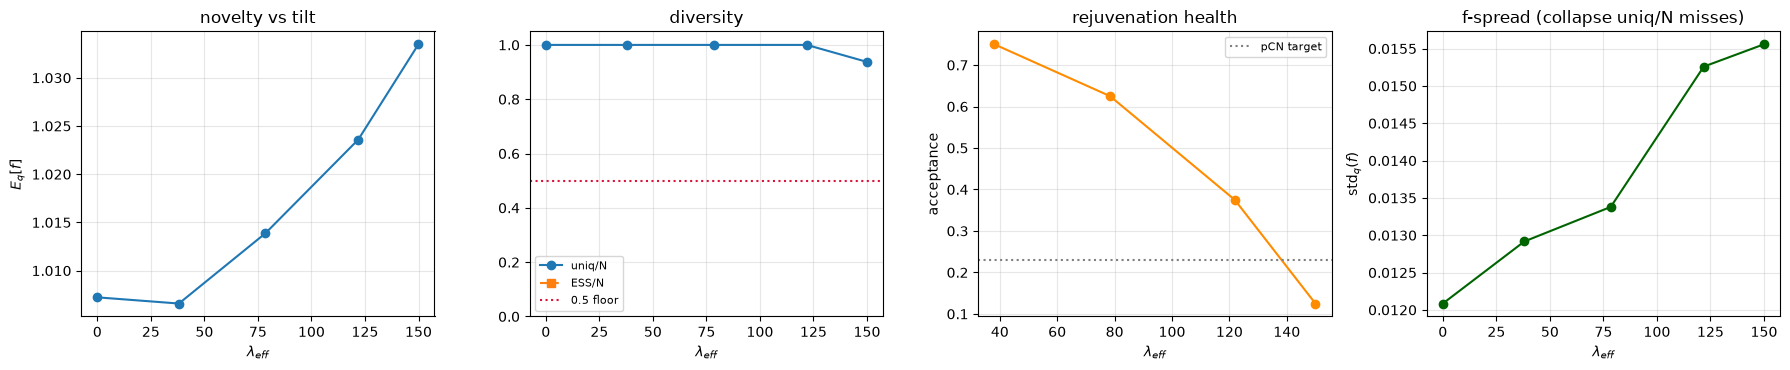

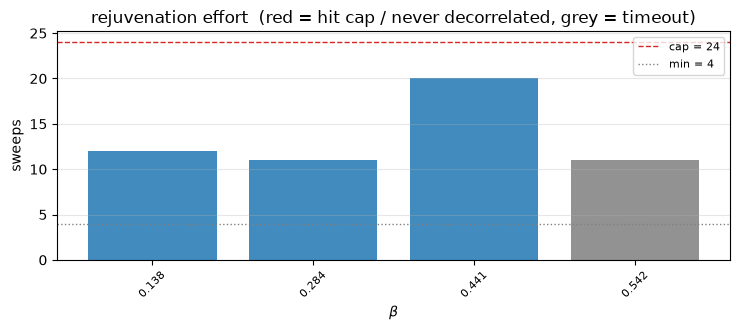

In [6]:
# --- results table --------------------------------------------------------------------------------
lam_eff = [l.lam_eff for l in levels]
Eqf = [float(l.fX.mean()) for l in levels]
f_sd = [float(l.fX.std()) for l in levels]
uniq = [int(l.X.unique(dim=0).shape[0]) / N for l in levels]
# ess_history holds RAW ESS counts in [1, N]; normalize to compare against the 0.5 floor.
# NOTE: on a deadline-truncated run this is all NaN -- ESS lives in the SMC loop, not the kernel.
# Known gap, deliberately not fixed for this run; acc and f-sd are the usable degeneracy signals.
ess = [float("nan")] + [float(e) / N for e in res.ess_history]
acc = [float("nan")] + [float(a) for a in res.acc_history]
sweeps = [0] + list(res.n_mcmc_history)
stops = ["-"] + list(res.stop_reason_history)
base_f = Eqf[0]

print(f"betas               = {[round(b, 4) for b in res.betas]}")
print(f"n_mcmc_history      = {res.n_mcmc_history}   (total {sum(res.n_mcmc_history)} sweeps)")
print(f"stop_reason_history = {res.stop_reason_history}")
print(f"\n{'k':>2} {'beta':>7} {'lam_eff':>9} {'m':>6} {'E_q[f]':>8} {'d f':>8} {'d f/sd':>7} "
      f"{'ESS/N':>6} {'acc':>6} {'uniq/N':>7} {'f-sd':>8} {'swp':>4} {'stop':>8}")
for k in range(len(levels)):
    print(f"{k:2d} {levels[k].beta:7.4f} {lam_eff[k]:9.1f} {lam_eff[k] / lam_s:6.2f} "
          f"{Eqf[k]:8.4f} {Eqf[k] - base_f:+8.4f} {(Eqf[k] - base_f) / f_sd[0]:7.1f} "
          f"{ess[k]:6.2f} {acc[k]:6.2f} {uniq[k]:7.2f} {f_sd[k]:8.4f} {sweeps[k]:4d} {stops[k]:>8}")

print(f"\nnovelty gain: E_q[f] {base_f:.4f} -> {Eqf[-1]:.4f} "
      f"({100 * (Eqf[-1] / base_f - 1):+.1f}%, {(Eqf[-1] - base_f) / f_sd[0]:.1f} sigma_p(f))")
print(f"reached beta {levels[-1].beta:.4f} of 1.0, m_eff {lam_eff[-1] / lam_s:.2f} of {M_TILT:.0f}")
# Prior runs, for orientation only -- sigma units are NOT comparable across gamma grids (Concl. 1b:
# c_window rescales the distance), so treat these as context, not as a like-for-like benchmark.
print(f"  prior: 693836 (g=3.5, N_gamma=6, m=3) +4.3% = 2.1 sigma, beta 1.00")
print(f"         694278 (g=1.5, N_gamma=6, m=5) +2.5% = 1.8 sigma, beta 0.135, m_eff 0.67")
n_cap = sum(1 for r in res.stop_reason_history if r == "cap")
print(f"levels hitting the sweep cap ({MAX_SWEEPS}): {n_cap}/{len(res.stop_reason_history)}"
      f"   (694278: 2/7 at the same cap)")

# --- diagnostics ----------------------------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
ax[0].plot(lam_eff, Eqf, "o-"); ax[0].set_ylabel(r"$E_q[f]$")
ax[0].set_title("novelty vs tilt")
ax[1].plot(lam_eff, uniq, "o-", label="uniq/N")
ax[1].plot(lam_eff, ess, "s--", label="ESS/N")
ax[1].axhline(0.5, color="crimson", ls=":", label="0.5 floor")
ax[1].set_ylim(0, 1.05); ax[1].legend(fontsize=8); ax[1].set_title("diversity")
ax[2].plot(lam_eff, acc, "o-", color="darkorange")
ax[2].axhline(0.23, color="grey", ls=":", label="pCN target")
ax[2].set_ylabel("acceptance"); ax[2].legend(fontsize=8); ax[2].set_title("rejuvenation health")
ax[3].plot(lam_eff, f_sd, "o-", color="darkgreen")
ax[3].set_ylabel(r"std$_q(f)$"); ax[3].set_title("f-spread (collapse uniq/N misses)")
for a in ax:
    a.set_xlabel(r"$\lambda_{eff}$"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, a = plt.subplots(figsize=(7.5, 3.4))
cols = ["tab:red" if r == "cap" else "tab:grey" if r == "timeout" else "tab:blue"
        for r in res.stop_reason_history]
a.bar(range(len(res.betas)), res.n_mcmc_history, color=cols, alpha=0.85)
a.axhline(MAX_SWEEPS, ls="--", color="tab:red", lw=1, label=f"cap = {MAX_SWEEPS}")
a.axhline(4, ls=":", color="grey", lw=1, label="min = 4")
a.set_xticks(range(len(res.betas)))
a.set_xticklabels([f"{b:.3f}" for b in res.betas], rotation=45, fontsize=8)
a.set_xlabel(r"$\beta$"); a.set_ylabel("sweeps"); a.legend(fontsize=8); a.grid(alpha=0.3, axis="y")
a.set_title("rejuvenation effort  (red = hit cap / never decorrelated, grey = timeout)")
plt.tight_layout(); plt.show()


decoded 5 levels x 16 particles


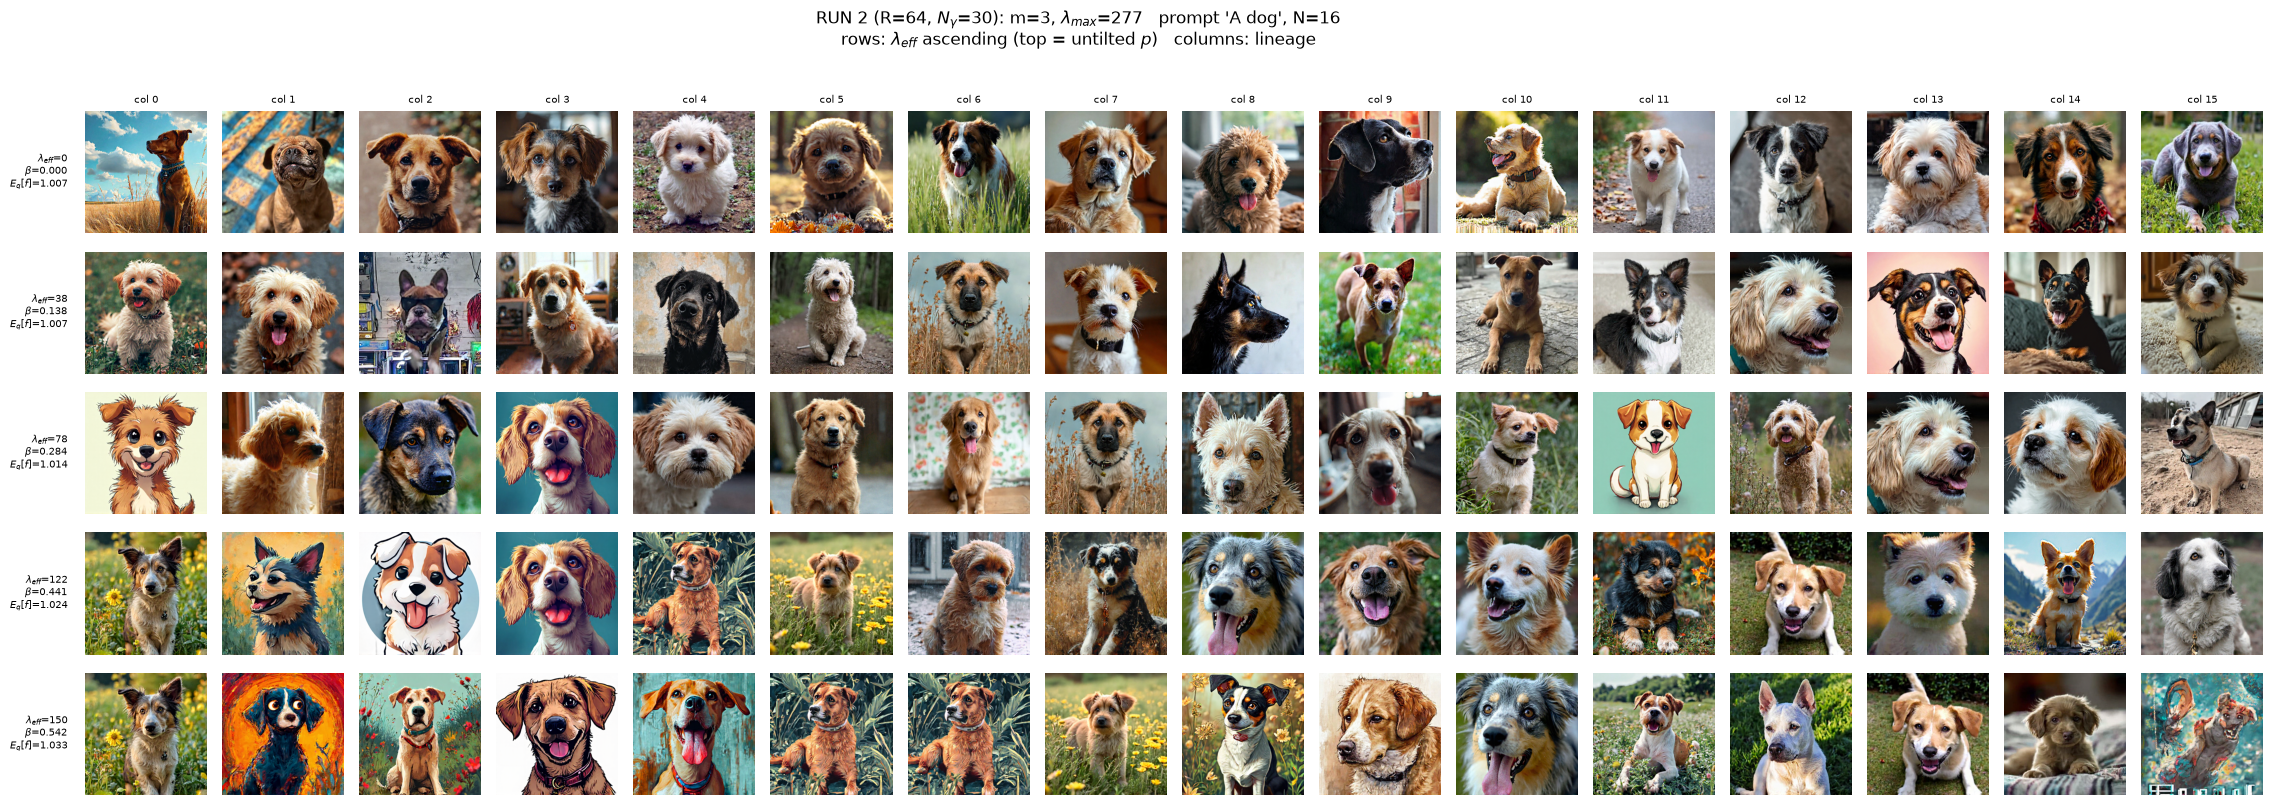

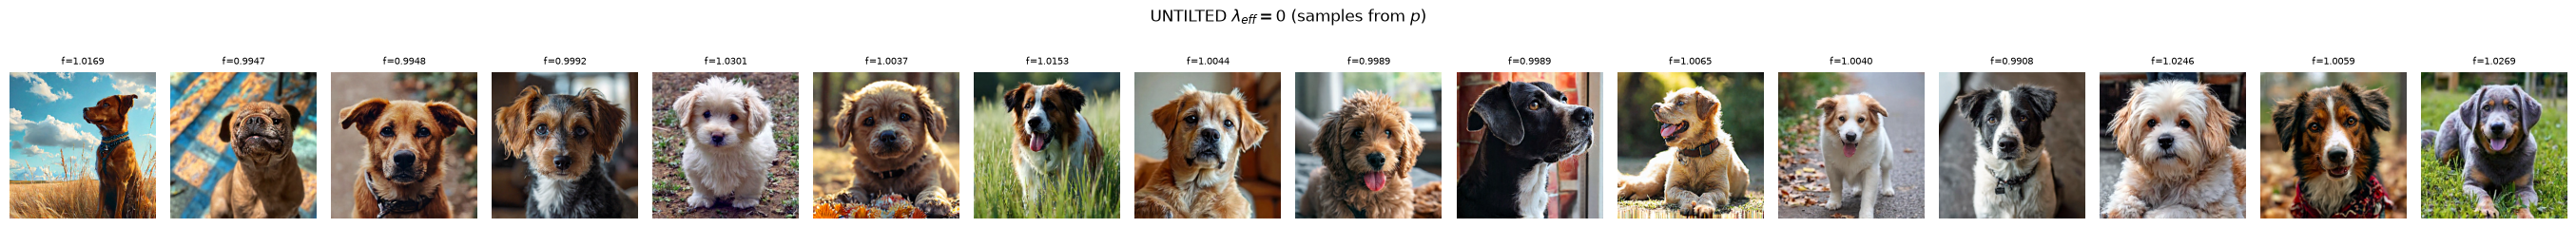

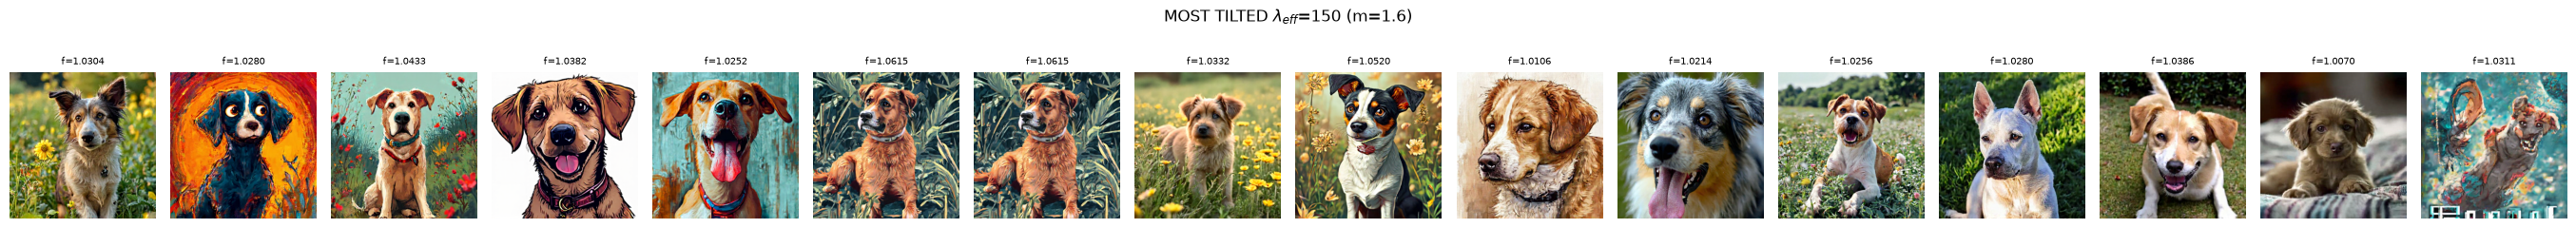

wrote 80 PNGs to decoded/ and strong_tilt_grid.png


In [7]:
# --- images ---------------------------------------------------------------------------------------
# Columns ordered by LINEAGE: walk `ancestors` backwards from the final level, so a column tracks one
# particle as the tilt strengthens. Repeated images across a row are resampler coalescence, which is
# information, not a defect. (On a timed-out run ancestors are arange, so this reduces to raw order.)
#
# Sizing: N doubled to 16, so per-column width and dpi are trimmed to keep the grid PNG manageable
# (at the old 2.0 in/col and dpi 140 a 16-wide grid would be ~4500 px and tens of MB).
col_of = [None] * len(levels)
cur = torch.arange(N)
col_of[-1] = cur
for k in range(len(levels) - 1, 0, -1):
    cur = levels[k].ancestors[cur]
    col_of[k - 1] = cur

decoded = [decode(l.X[col_of[k]]) for k, l in enumerate(levels)]
print(f"decoded {len(levels)} levels x {N} particles")

nrow = len(levels)
fig, axes = plt.subplots(nrow, N, figsize=(N * 1.5, nrow * 1.65), squeeze=False)
for k in range(nrow):
    for j in range(N):
        a = axes[k][j]
        a.axis("off")
        a.imshow(decoded[k][j].permute(1, 2, 0).clamp(0, 1).numpy())
        if j == 0:
            a.text(-0.14, 0.5, f"$\\lambda_{{eff}}$={lam_eff[k]:.0f}\n$\\beta$={levels[k].beta:.3f}\n"
                               f"$E_q[f]$={Eqf[k]:.3f}",
                   transform=a.transAxes, ha="right", va="center", fontsize=7)
        if k == 0:
            a.set_title(f"col {j}", fontsize=7)
fig.suptitle(f"RUN 2 (R={R}, $N_\\gamma$={N_GAMMA}): m={M_TILT:.0f}, "
             f"$\\lambda_{{max}}$={LAM_MAX:.0f}   prompt {PROMPT!r}, N={N}\n"
             f"rows: $\\lambda_{{eff}}$ ascending (top = untilted $p$)   columns: lineage", fontsize=12)
plt.tight_layout(rect=(0.05, 0, 1, 0.965))
plt.show()
fig.savefig(os.path.join(SWEEP_DIR, "strong_tilt_grid.png"), dpi=110, bbox_inches="tight")

# Untilted anchor vs most tilted, enlarged, for a direct visual read on what the tilt did.
for k, label in ((0, "UNTILTED $\\lambda_{eff}=0$ (samples from $p$)"),
                 (len(levels) - 1, f"MOST TILTED $\\lambda_{{eff}}$={lam_eff[-1]:.0f} "
                                   f"(m={lam_eff[-1] / lam_s:.1f})")):
    fig, axes = plt.subplots(1, N, figsize=(N * 1.7, 2.4), squeeze=False)
    for j in range(N):
        a = axes[0][j]
        a.axis("off")
        a.imshow(decoded[k][j].permute(1, 2, 0).clamp(0, 1).numpy())
        a.set_title(f"f={float(levels[k].fX[col_of[k][j]]):.4f}", fontsize=7)
    fig.suptitle(label, fontsize=12)
    plt.tight_layout(rect=(0, 0, 1, 0.90)); plt.show()

# Per-image PNGs for full-resolution inspection.
from PIL import Image

os.makedirs(os.path.join(SWEEP_DIR, "decoded"), exist_ok=True)
for k in range(len(levels)):
    for j in range(N):
        arr = (decoded[k][j].permute(1, 2, 0).clamp(0, 1) * 255).round().to(torch.uint8).numpy()
        Image.fromarray(arr).save(
            os.path.join(SWEEP_DIR, "decoded", f"lvl{k:02d}_lam{lam_eff[k]:.0f}_col{j}.png"))
print(f"wrote {len(levels) * N} PNGs to decoded/ and strong_tilt_grid.png")


## Takeaways

*(Fill in after the run — this cell is the authoritative statement of what was learned, per repo convention.)*

**The question.** 694278 showed the tilt visibly moving samples photographic → illustrated, but the cross-check
against `demo_properties.ipynb` showed the reward was off-calibration in ways that could produce exactly that
artefact: $N_\gamma = 6$ against a calibrated $\ge 25$ (Concl. 2), and a $\gamma$ weighting dominated by the
lowest interval, which sits on the Euclidean floor where the integrand degenerates to $\|x_1 - x_2\|^2$
(Concl. 1a/1b). **This run asks whether the style axis survives a converged $f$.** $N_\gamma$ 6 → 30 is the
variable of interest; $R$ 4 → 64 rides along because the cached distance made it free.

**The three outcomes, and what each would mean:**

- **Style movement persists at $N_\gamma = 30$.** Then it is a property of the IEM under this $p$, not a
  quadrature artefact, and the "which axis of novelty" question becomes real. Next lever is the $\gamma$
  window ($C = 1.00 \to 0.75$), which this run deliberately held fixed.
- **Style movement disappears.** Then 694278's headline finding was an artefact of the coarse grid, and the
  takeaways in `../flux_lambda_sweep_strong/run_694278.ipynb` §3 need amending — say so explicitly there.
- **Too few levels to tell.** The most likely outcome on the $\Delta\beta$ evidence. Then the run is a cost
  calibration, not a result, and the honest next step is a fixed-$\lambda$ target rather than $\beta \to 1$.

**To record:**

- Levels reached, $\beta$ and $m_{\text{eff}}$ attained, whether the deadline truncated
- **Measured `s_row` vs the 0.250 s/row implied by 694278's pre-migration 165 s sweep** — this is the first
  real measurement of the cached distance, and every future projection depends on it
- **Actual vs projected sweep cost** (printed at the end of the run cell). Both prior jobs overran their
  projection by 1.4–1.6×; if that persists, the cost model is still wrong and needs a different basis
- $\operatorname{std}_p(f)$ and $\lambda_s$ at $N_\gamma = 30$, from 32 probes — and whether the level-0 cloud
  now agrees with the probe (694278's disagreed by 3.6× on 8 draws each)
- $\Delta\beta$ per level vs 694278's 0.019 at $m = 5$: did $m = 3$ and `ESS_TARGET` 0.80 actually widen the steps?
- `stop_reason_history`: how many levels hit the cap at 24 (694278: 2 of 7)
- Acceptance floor and $f$-spread trajectory — with `ESS/N` still NaN on a truncated run, these are the only
  usable degeneracy signals
- Visual verdict: row 0 vs 694278's row 0 (both at guidance 1.5, so this isolates the reward change), and the
  most-tilted row vs row 0

**Caveats.** Rows share ancestry and are not independent draws from $q_{\lambda_{\text{eff}}}$;
$\lambda_{\text{eff}}$ values are chosen by the ESS rule, not by us; **$\sigma$ units are not comparable to any
previous run** because the $\gamma$ grid changed and Concl. 1b's $c_{\text{window}}$ rescales the distance;
`uniq/N` can read 1.00 for a collapsed ensemble because pCN moves duplicated particles apart; and `ESS/N` is
NaN on a truncated run, so the established $\lambda$-selection rule remains inapplicable — a known gap carried
into this run on purpose.
